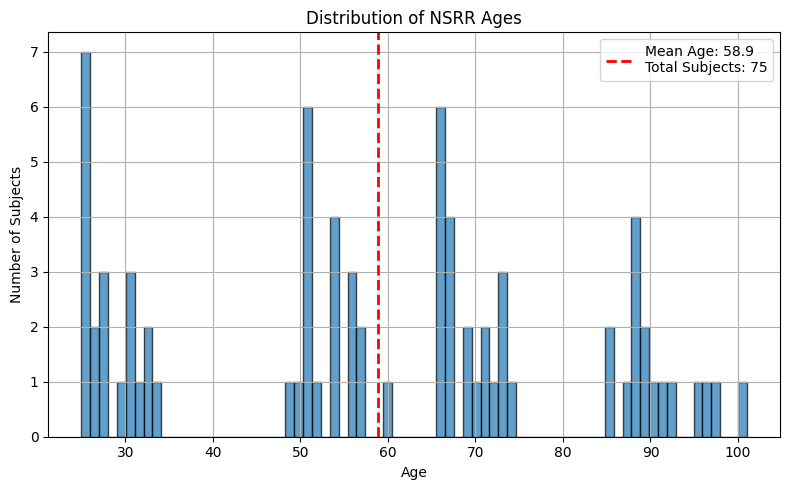

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cleaned CSV file
df = pd.read_csv("F://physioex_dir//physioex//datasets//sleepedf//table.csv")  

# Ensure ages are numeric and clean any bad values
df['nsrr_age'] = pd.to_numeric(df['nsrr_age'], errors='coerce')
df = df.dropna(subset=['nsrr_age'])

# Calculate the mean
mean_age = df['nsrr_age'].mean()
num_subjects = len(df)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(df['nsrr_age'], bins=75, edgecolor='black', alpha=0.7)
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean Age: {mean_age:.1f}')

# Plot details
plt.title('Distribution of NSRR Ages')
plt.xlabel('Age')
plt.ylabel('Number of Subjects')
plt.legend([f'Mean Age: {mean_age:.1f}\nTotal Subjects: {num_subjects}'])
plt.grid(True)
plt.tight_layout()
plt.show()


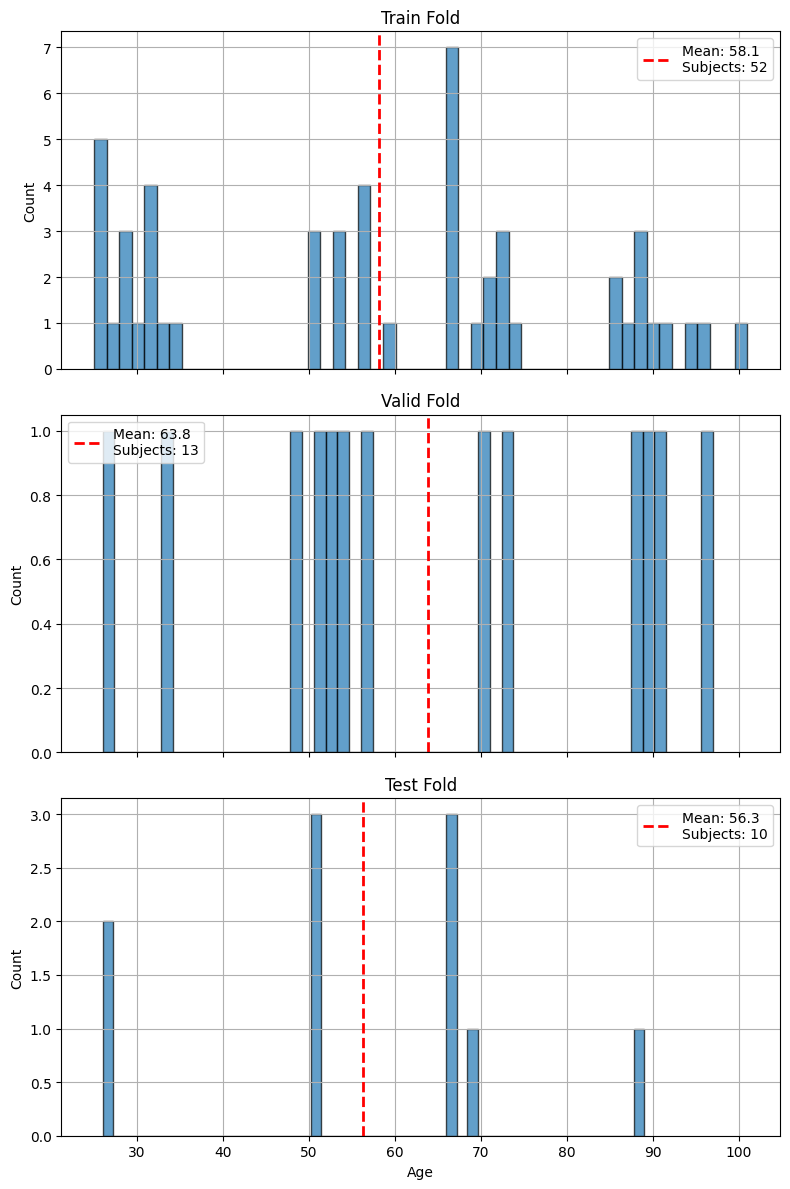

In [9]:
folds = ['train', 'valid', 'test']
fig, axes = plt.subplots(len(folds), 1, figsize=(8, 12), sharex=True)


train_subjects = len(df[df['fold_0'] == 'train'])
fixed_bins = train_subjects if train_subjects > 1 else 1

for i, fold in enumerate(folds):
    df_fold = df[df['fold_0'] == fold]
    mean_fold = df_fold['nsrr_age'].mean()
    count_fold = len(df_fold)
        
    axes[i].hist(df_fold['nsrr_age'], bins=fixed_bins, edgecolor='black', alpha=0.7)
    axes[i].axvline(mean_fold, color='red', linestyle='dashed', linewidth=2)
    axes[i].set_title(f'{fold.capitalize()} Fold')
    axes[i].set_ylabel('Count')
    axes[i].legend([f'Mean: {mean_fold:.1f}\nSubjects: {count_fold}'])
    axes[i].grid(True)

axes[-1].set_xlabel('Age')
plt.tight_layout()
plt.show()